Contents:

[Part 1. Run the algorithms](###-Part-1.-Run-the-algorithms)

[Part 2. Plots](###-Part-2.-Plots)

[Part 3. Learning Rate Experiment](###-Part-3.-Learning-Rate-Experiment)

---

Import the classes from optimizer_benchmark

In [ ]:
import importlib # This helps to rerun cells without restarting the kernel
import optimizer_benchmark
importlib.reload(optimizer_benchmark)

from optimizer_benchmark import Update_Parameter as up
from optimizer_benchmark import Plot

### Part 1. Run the algorithms

Loss Function:

$f(x, y) = x^2 + 20y^2$

In [32]:
def loss(x, y):
    return x**2 + 20*y**2

Gradient:

$∇f(x, y) = [2x, 40y]$

In [33]:
def gradient(x, y):
    return 2*x, 40*y

Starting point

In [34]:
x = 8.0
y = 8.0

In [35]:
print(f'Loss value at ({x}, {y}) = {loss(8, 8)}\nGradient at ({x}, {y}) = {gradient(x, y)}')

Loss value at (8.0, 8.0) = 1344
Gradient at (8.0, 8.0) = (16.0, 320.0)


Initial Learning Rate & Iterations

In [36]:
lr = 0.05
iterations = 100

Now we run the algorithms.

Each one returns x_list, y_list, losses, gradients and effective learning rate (if it has adaptive lr) in order.

In [37]:
gd =  up.gradient_descent(loss, gradient, x, y, lr=lr, iterations=iterations)
m =  up.momentum(loss, gradient, x, y, lr=lr, iterations=iterations)
ag =  up.adagrad(loss, gradient, x, y, lr=lr, iterations=iterations)
r =  up.rmsprop(loss, gradient, x, y, lr=lr, iterations=iterations)
a =  up.adam(loss, gradient, x, y, lr=lr, iterations=iterations)
aw =  up.adamw(loss, gradient, x, y, lr=lr, iterations=iterations)

In [38]:
up.result(gd, m, ag, r, a, aw)

     Algorithm     |   Final x   |   Final y   |   Final Loss   
---------------------------------------------------------------
  Gradient Descent |   0.0002    |   8.0000    |    1280.00 
      Momentum     |   0.0299    |   0.0569    |       0.07 
      AdaGrad      |   7.0911    |   7.0911    |    1055.96 
      RMSprop      |   2.9277    |   2.9277    |     180.00 
       Adam        |   3.6378    |   3.6378    |     277.90 
       AdamW       |   3.4101    |   3.4101    |     244.20 


### Part 2. Plots

In [39]:
lr = 0.05
iterations = 100

gd =  up.gradient_descent(loss, gradient, x, y, lr=lr, iterations=iterations)
m =  up.momentum(loss, gradient, x, y, lr=lr, iterations=iterations)
ag =  up.adagrad(loss, gradient, x, y, lr=lr, iterations=iterations)
r =  up.rmsprop(loss, gradient, x, y, lr=lr, iterations=iterations)
a =  up.adam(loss, gradient, x, y, lr=lr, iterations=iterations)
aw =  up.adamw(loss, gradient, x, y, lr=lr, iterations=iterations)

1. Iteration vs Loss

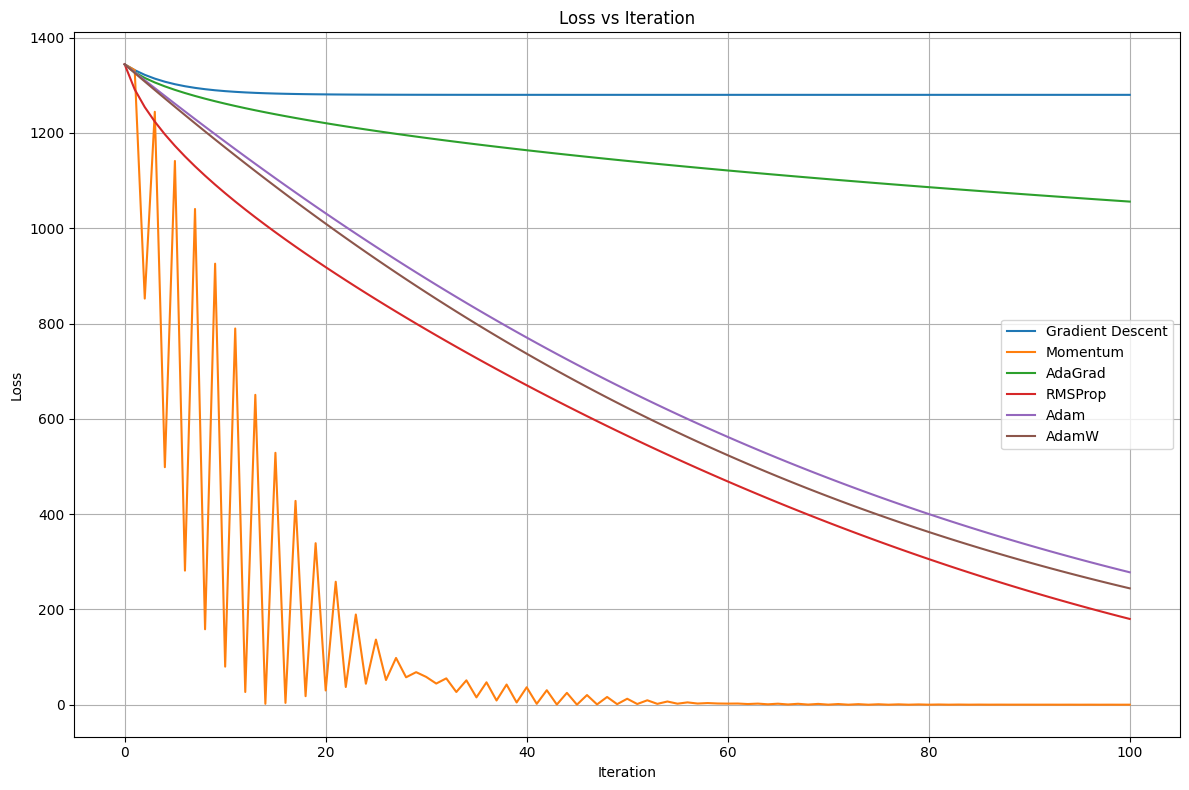

In [40]:
losses = [gd[2], m[2], ag[2], r[2], a[2], aw[2]]

Plot.loss_vs_iter(losses, title='Loss vs Iteration')

2. Contour Plot

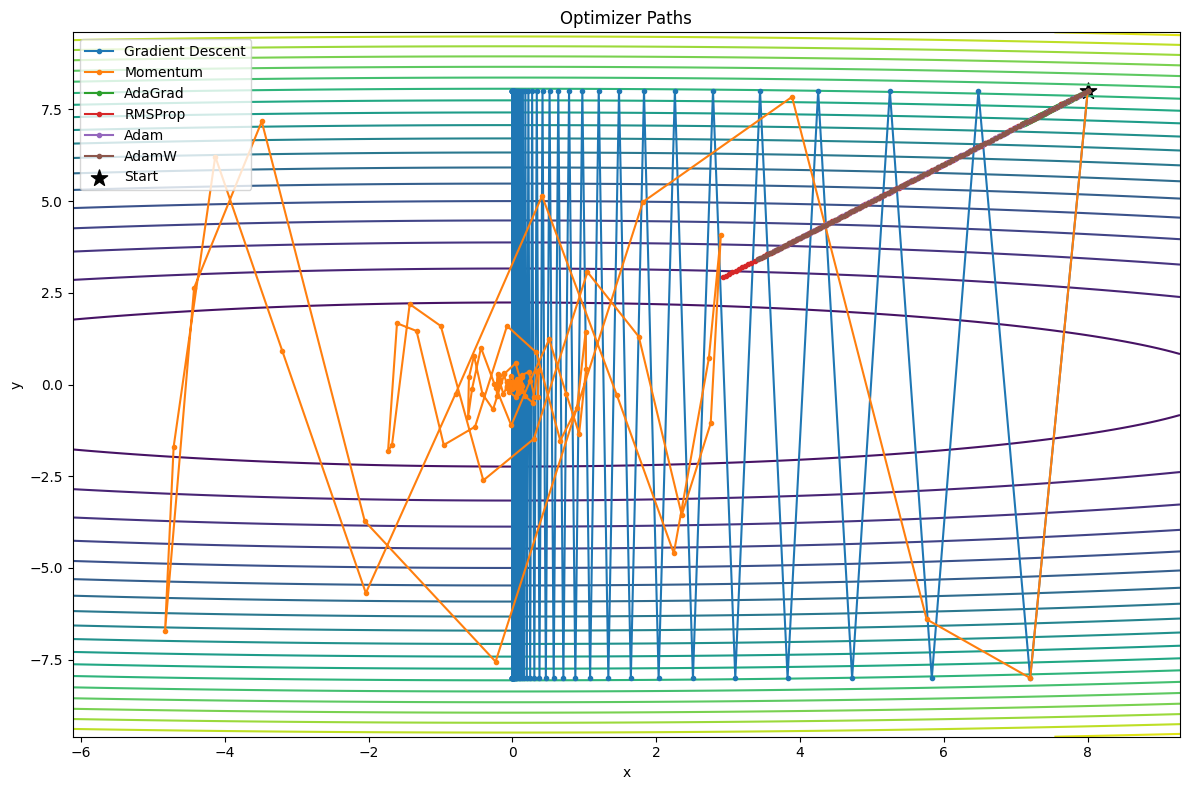

In [41]:
X_list = [gd[0], m[0], ag[0], r[0], a[0], aw[0]]                                      
Y_list = [gd[1], m[1], ag[1], r[1], a[1], aw[1]]

Plot.contour_plot(
    loss,
    X_list,
    Y_list,
    title="Optimizer Paths"
    )

3. Gradient Descent vs Adam

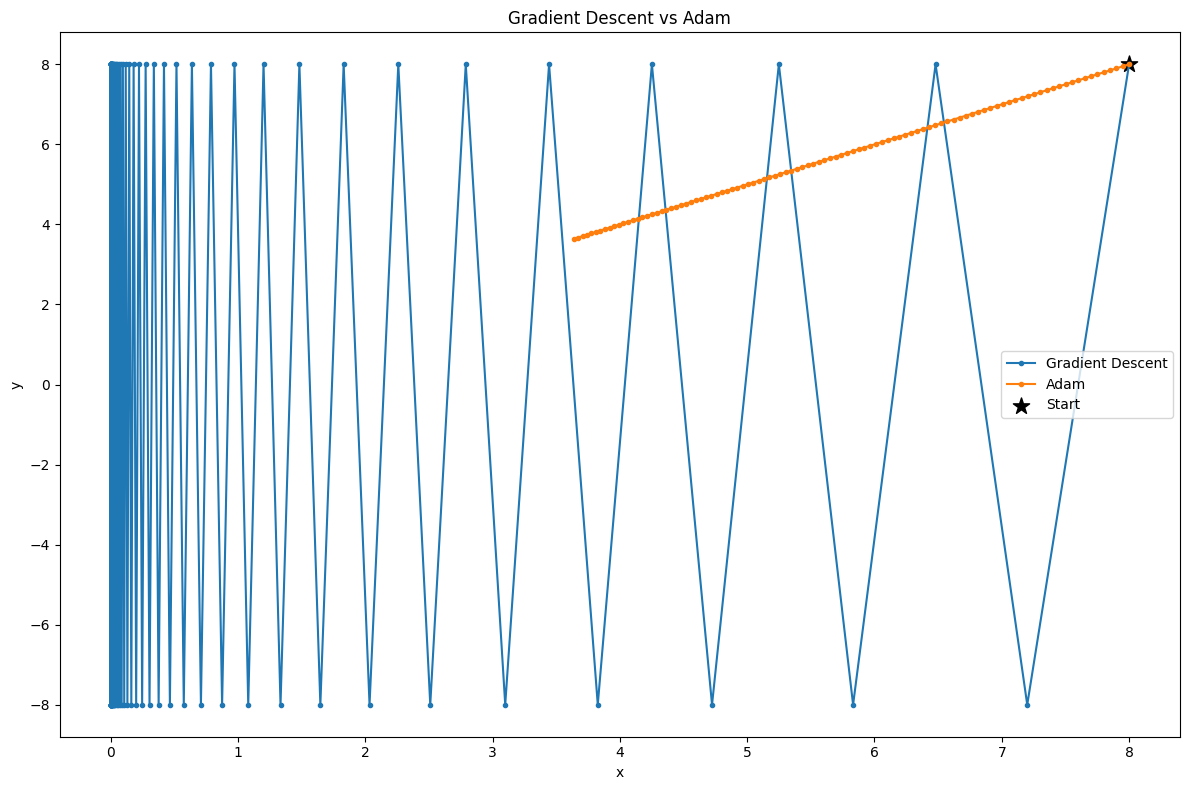

Gradient Descent:
Final (x, y) = (0.000, 8.000)
Final loss = 1280.000

Adam:
Final (x, y) = (3.638, 3.638)
Final loss = 277.899


In [42]:
Plot.gd_vs_adam(
    gd,
    a,
    title="Gradient Descent vs Adam"
    )

### Part 3. Learning Rate Experiment

Run Adam with different learning rates.

- LR = 0.001

In [43]:
iters = [100, 1000, 10000]

print(f"\nLR = {0.001}:\n")

for iter in iters:
    a = up.adam(loss, gradient, x, y, lr=0.001, iterations=iter)
    print(
    f"Iter = {iter}\n"
    f"Start = ({a[0][0]:.3f}, {a[1][0]:.3f})\n"
    f"End = ({a[0][-1]:.3f}, {a[1][-1]:.3f})\n"
    f"Final Loss = {a[2][-1]:.3f}\n"
    )


LR = 0.001:

Iter = 100
Start = (8.000, 8.000)
End = (7.900, 7.900)
Final Loss = 1310.680

Iter = 1000
Start = (8.000, 8.000)
End = (7.027, 7.027)
Final Loss = 1037.092

Iter = 10000
Start = (8.000, 8.000)
End = (0.354, 0.354)
Final Loss = 2.635



**Did it converge?**

After 1000 iterations, it is still near the starting point. but with 10000, there is a sign of convergence.

**How fast was convergence?**

It is very slow.

**Did you observe oscillation or divergence?**

Neither oscillatory nor divergent, the updates are small and smooth.

**Why did this behaviour happen?**

We know that Adam normalizes the gradient, but the overall update is still scaled by 0.001, so each step is tiny.

- LR = 0.05

In [44]:
iters = [100, 1000, 10000]

print(f"\nLR = {0.05}:\n")

for iter in iters:
    a = up.adam(loss, gradient, x, y, lr=0.05, iterations=iter)
    print(
    f"Iter = {iter}\n"
    f"Start = ({a[0][0]:.3f}, {a[1][0]:.3f})\n"
    f"End = ({a[0][-1]:.3f}, {a[1][-1]:.3f})\n"
    f"Final Loss = {a[2][-1]:.3f}\n"
    )


LR = 0.05:

Iter = 100
Start = (8.000, 8.000)
End = (3.638, 3.638)
Final Loss = 277.899

Iter = 1000
Start = (8.000, 8.000)
End = (-0.000, -0.000)
Final Loss = 0.000

Iter = 10000
Start = (8.000, 8.000)
End = (0.000, 0.000)
Final Loss = 0.000



**Did it converge?**

Yes, with less than 1000 iterations, it moved toward (0, 0).

**How fast was convergence?**

Moderate but much faster than 0.001.

**Did you observe oscillation or divergence?**

There is no strong oscillation and no divergence. The direction is smooth.

**Why did this behaviour happen?**

The learning rate is large enough to make useful progress each iteration, but not so large that Adam continually overshoots the minimum.

- LR = 0.5

In [45]:
iters = [100, 1000, 10000]

print(f"\nLR = {0.5}:\n")

for iter in iters:
    a = up.adam(loss, gradient, x, y, lr=0.5, iterations=iter)
    print(
    f"Iter = {iter}\n"
    f"Start = ({a[0][0]:.3f}, {a[1][0]:.3f})\n"
    f"End = ({a[0][-1]:.3f}, {a[1][-1]:.3f})\n"
    f"Final Loss = {a[2][-1]:.3f}\n"
    )


LR = 0.5:

Iter = 100
Start = (8.000, 8.000)
End = (0.041, 0.041)
Final Loss = 0.035

Iter = 1000
Start = (8.000, 8.000)
End = (-0.000, -0.000)
Final Loss = 0.000

Iter = 10000
Start = (8.000, 8.000)
End = (-0.000, -0.000)
Final Loss = 0.000



**Did it converge?**

Yes, approximately. This is clearly the best of the three within 100 iterations.

**How fast was convergence?**

Very fast compared with the other two learning rates.

**Did you observe oscillation or divergence?**

Yes, oscillation happens. The optimizer repeatedly overshoots and comes back toward the minimum. However, the oscillations decrease in magnitude, so the method does not diverge.

**Why did this behaviour happen?**

A learning rate of 0.5 produces very large Adam updates. Near the optimum, those updates can move the parameters from one side of zero to the other, producing oscillations. Adam's adaptive normalization keeps the process stable enough that these oscillations gradually shrink rather than exploding.